# Student Performance Indicator

### Life Cycle of this project
1. Understanding the problem statement
2. Data Collection
3. Data Cleaning, EDA, and Feature Engineering
4. Data Pre-processing
5. Model Training
6. Model Testing

## 1. Problem Statement

The dataset is about to understand the influence of the parents background, test preparation etc on students performance. We have to Predict the Maths score based on the given feature.

## 2. Data Collection

The data is collected from https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977 consists of 8 columns and 1000 rows.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

df=pd.read_csv('data/StudentsPerformance.csv')
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 3. Data Cleaning, EDA, and Feature Engineering

#### 3.1 Removing duplicated and null values

In [2]:
print("Total Duplicated Value are: ", df.duplicated().sum())
print("Total null values are: ", df.isnull().sum())

Total Duplicated Value are:  0
Total null values are:  gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


#### 3.2 different number of columns

In [3]:
# There are 5 string and 3 integer columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


#### 3.3 Numerical Features Statistics

In [4]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### 3.4 Number of unique Values 

<Axes: title={'center': 'Frequency of Unique Values in Overall Features'}, xlabel='Dataset Features', ylabel='Number of Unique Vales'>

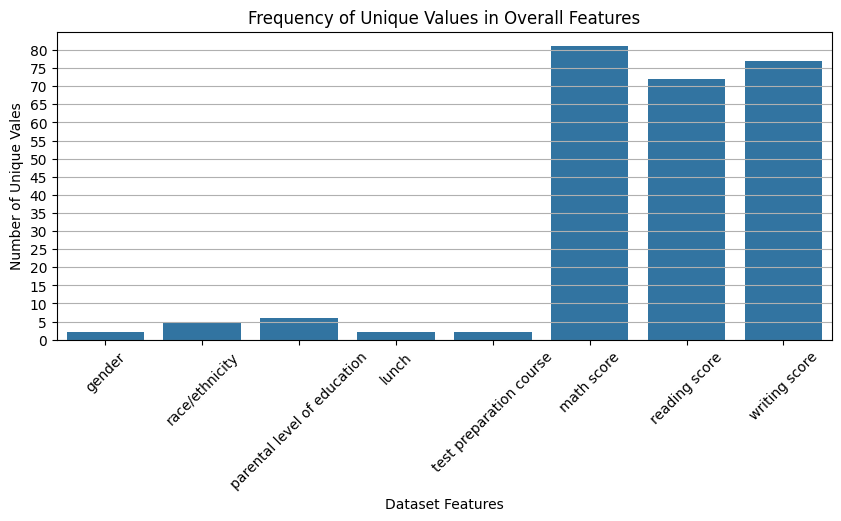

In [5]:
plt.figure(figsize=(10, 4))
plt.xticks(rotation=45)
plt.yticks([i for i in range(0, 82, 5)])
plt.grid()
plt.xlabel('Dataset Features')
plt.ylabel('Number of Unique Vales')
plt.title("Frequency of Unique Values in Overall Features")
sns.barplot(df.nunique())

#### 3.5 Checking Feature Names

In [6]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

#### 3.6 # What are unique values in the categorical features

In [7]:

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"{col}:\n", df[col].unique(), "\n")

gender:
 <StringArray>
['female', 'male']
Length: 2, dtype: str 

race/ethnicity:
 <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str 

parental level of education:
 <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str 

lunch:
 <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str 

test preparation course:
 <StringArray>
['none', 'completed']
Length: 2, dtype: str 



C:\Users\z1652\AppData\Local\Temp\ipykernel_5504\1660057462.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In 'parental level of education' there is 'high school' and 'some high school' that can be one.

In [8]:
# Combine the similar parental education categories
# 'some high school' can be grouped with 'high school' for this analysis
if 'parental level of education' in df.columns:
    df['parental level of education'] = df['parental level of education'].replace({'some high school': 'high school'})
    print(df['parental level of education'].value_counts())
else:
    print('Column not found: parental level of education')
df.to_csv('data/StudentsPerformance_cleaned.csv', index=False)

parental level of education
high school           375
some college          226
associate's degree    222
bachelor's degree     118
master's degree        59
Name: count, dtype: int64


### 3.8 Feature Engineering part

#### 3.8.1 Feature Extraction

In [9]:
df['Total Score'] = df['math score'] + df['reading score'] + df['writing score']
df['Average_Score'] = df['Total Score'] / 3
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Average_Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


<Axes: xlabel='Average_Score', ylabel='Count'>

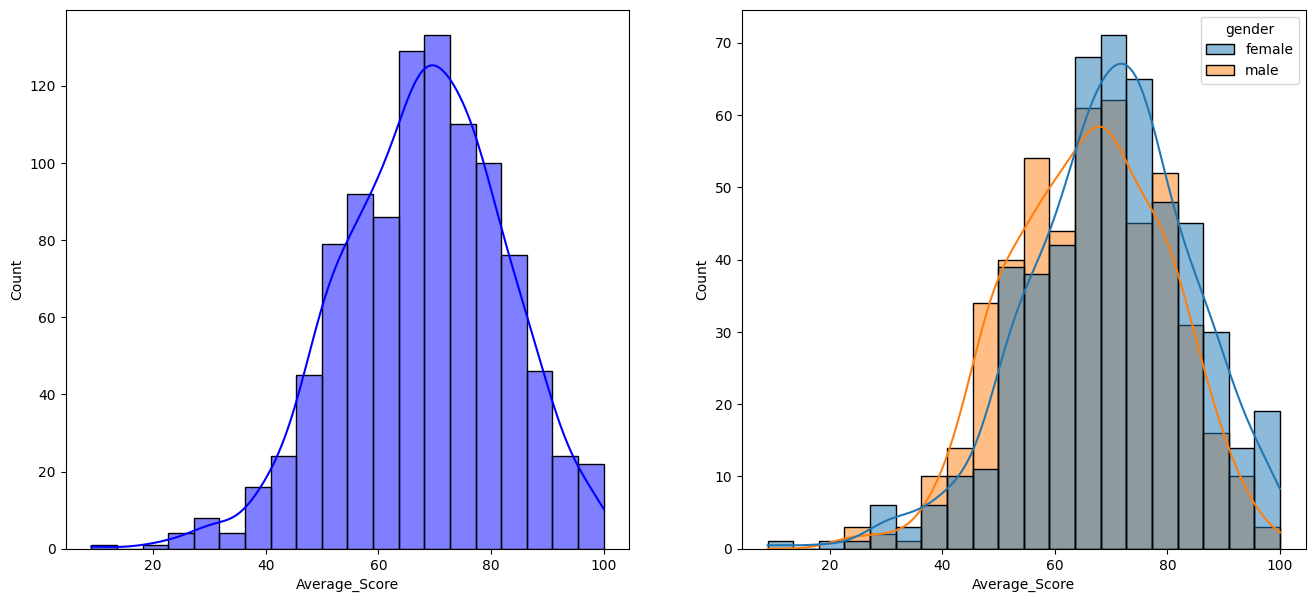

In [10]:
plt.figure(figsize=(16, 7))
plt.subplot(1, 2, 1)
sns.histplot(df['Average_Score'], kde=True, bins=20, color='blue', edgecolor='black')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x=df['Average_Score'], kde=True, bins=20, color='hotpink', edgecolor='black', hue='gender', )

Insights: Based on Overall Average Score the Female Students are performing well

## 3.9 Additional EDA

### 3.9.1 Additional EDA: correlation 

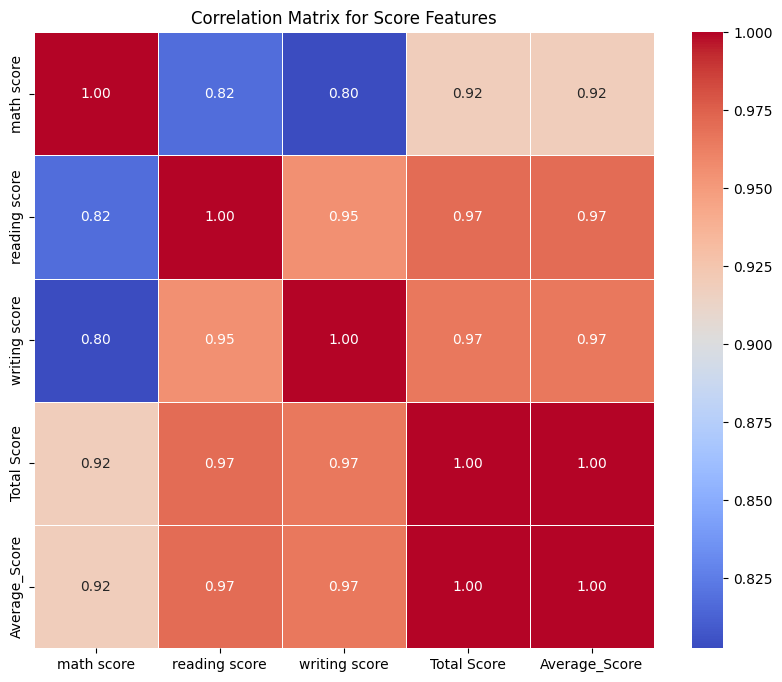

In [11]:

numeric_cols = ['math score', 'reading score', 'writing score', 'Total Score', 'Average_Score']
corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix for Score Features')
plt.show()

### 3.9.2 Categorical relationships

C:\Users\z1652\AppData\Local\Temp\ipykernel_5504\901976480.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='test preparation course', y='Average_Score', data=df, palette='pastel')
C:\Users\z1652\AppData\Local\Temp\ipykernel_5504\901976480.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='lunch', y='Average_Score', data=df, palette='Set2')
C:\Users\z1652\AppData\Local\Temp\ipykernel_5504\901976480.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='parental level of education', y='Average_Score', data=df, order=order, palette='

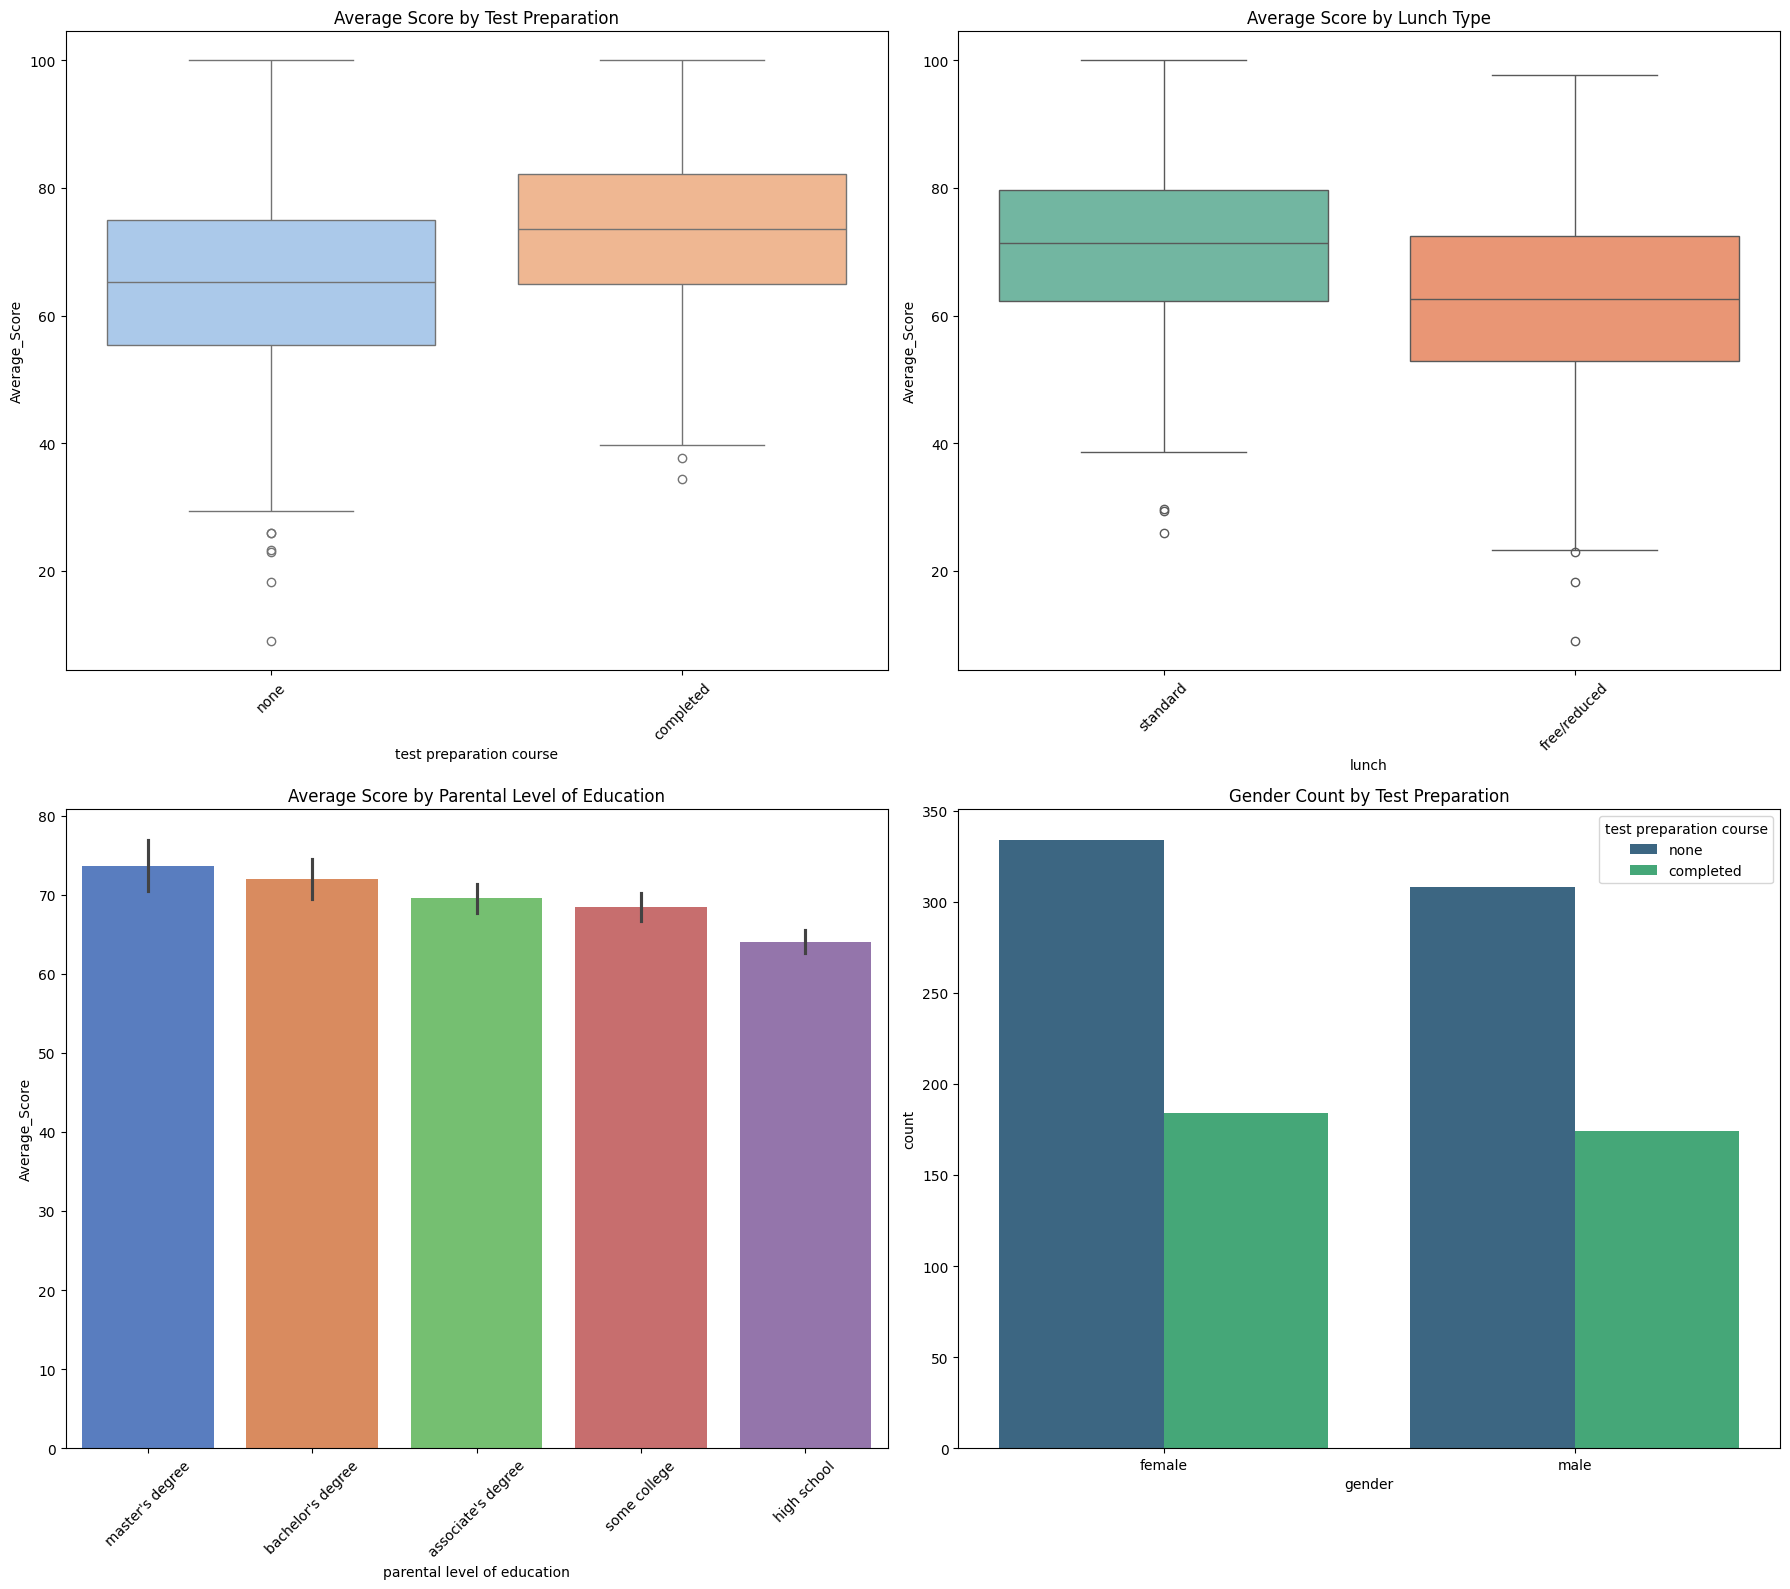

In [12]:


plt.figure(figsize=(18, 16))
plt.subplot(2, 2, 1)
sns.boxplot(x='test preparation course', y='Average_Score', data=df, palette='pastel')
plt.title('Average Score by Test Preparation')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
sns.boxplot(x='lunch', y='Average_Score', data=df, palette='Set2')
plt.title('Average Score by Lunch Type')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
order = df.groupby('parental level of education')['Average_Score'].mean().sort_values(ascending=False).index
sns.barplot(x='parental level of education', y='Average_Score', data=df, order=order, palette='muted')
plt.title('Average Score by Parental Level of Education')
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
sns.countplot(x='gender', hue='test preparation course', data=df, palette='viridis')
plt.title('Gender Count by Test Preparation')
plt.tight_layout()
plt.show()

### 3.9.3  Additional grouped insights from categorical features

In [13]:

print('Average Score by Race/Ethnicity and Gender:')
print(df.groupby(['race/ethnicity', 'gender'])['Average_Score'].mean().unstack(), '\n')

print('Average Score by Parental Education and Lunch:')
print(df.groupby(['parental level of education', 'lunch'])['Average_Score'].mean().round(2))

Average Score by Race/Ethnicity and Gender:
gender             female       male
race/ethnicity                      
group A         65.129630  61.540881
group B         67.509615  63.000000
group C         68.585185  65.249400
group D         71.439276  66.987469
group E         74.062802  71.478873 

Average Score by Parental Education and Lunch:
parental level of education  lunch       
associate's degree           free/reduced    65.43
                             standard        71.77
bachelor's degree            free/reduced    67.05
                             standard        74.82
high school                  free/reduced    57.31
                             standard        67.68
master's degree              free/reduced    67.11
                             standard        78.05
some college                 free/reduced    62.97
                             standard        71.44
Name: Average_Score, dtype: float64


In [14]:
# df.to_csv('data/StudentsPerformance_cleaned.csv', index=False)
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Average_Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333
